# Evaluate the minimum P wave pulse resolution

We demonstrate the minimum resolution of the P wave displacement pulse after applying the band-pass filter. We also evaluate the effect of waterlevel during the deconvolution of attenuation factor on the pulse width.

2025.11.25 Kurama Okubo

- 2026.1.20 update for event labels.

In [1]:
import os
import obspy
from obspy import read, Stream, Trace
from scipy import signal
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline
from glob import glob
import numpy as np
import mpmath as mp
import pandas as pd
from tqdm import tqdm
import warnings

import matplotlib as mpl
import copy

import seaborn as sns 

from scipy.interpolate import CubicSpline

from STFfit_func import *

plt.rcParams["font.family"] = 'Arial'
# plt.rcParams["font.sans-serif"] = "DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif"
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 4.75
plt.rcParams["xtick.major.width"] = 0.75
plt.rcParams["xtick.minor.size"] = 3
plt.rcParams["xtick.minor.width"] = 0.4
plt.rcParams["xtick.minor.visible"] = True

plt.rcParams["ytick.direction"] = "in"
plt.rcParams["ytick.major.size"] = 4.75
plt.rcParams["ytick.major.width"] = 0.75
plt.rcParams["ytick.minor.size"] = 3
plt.rcParams["ytick.minor.width"] = 0.4
plt.rcParams["ytick.minor.visible"] = True

plt.rcParams["savefig.transparent"] = True
plt.rcParams['axes.linewidth'] = 0.75

from obspy.core.utcdatetime import UTCDateTime  
os.environ['TZ'] = 'GMT' # change time zone to avoid confusion in unix_tvec conversion
UTCDateTime.DEFAULT_PRECISION = 8

In [2]:
figdir = "../figure/"
if not os.path.exists(figdir):
    os.makedirs(figdir)

# Read Green's function
We use the Green's function computed by the 3d waveform propagation modeling.

In [3]:
event_id = 52
gougepatch_id = "P3"

finame = f'../../../../SourceInvFit/data/06_assemble_gf_model4/fb03-087__{event_id:04d}_AEwaveform.pickle'
st_event = read(finame)

In [4]:
stationid = 8
tr_obs = st_event.select(station=f'OL{stationid:02d}', location='stage1')[0].filter("highpass", freq=6e4)
tr_green_xy = st_event.select(station=f'OL{stationid:02d}', location='GF', channel='G_Vz_mxy')[0]


**Note** Synthetic Green's function is computed using OpenSWPC with Qp = 200.

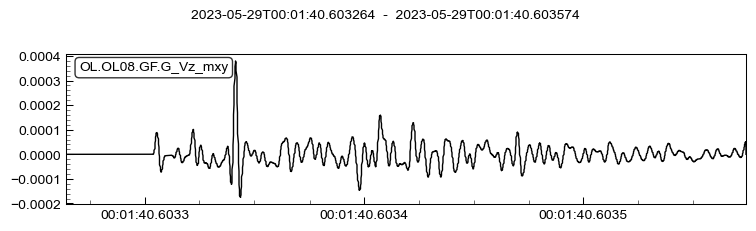

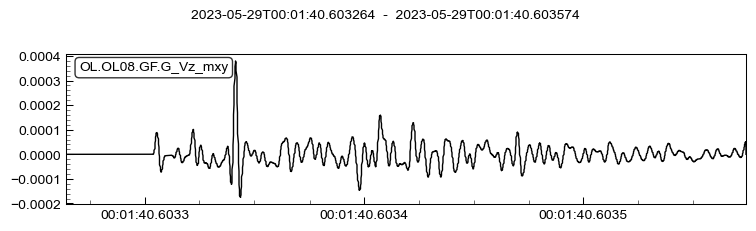

In [5]:
tr_green_xy.plot()

In [6]:
# The Green's function from OpenSWPC was convolved by the predescribed source time function.
# We deconvolve it to obtain the Green's function with an impulse imput.
TR_input = 5.0e-6 # set at the input file of OpenSWPC
TR_new = 1.0e-6 # impulse-like short duration STF
k_waterlevel_green = 1e-6

In [7]:
dt = tr_green_xy.stats.delta

# Source time function pre-convolved in the OpenSWPC
tvec_STF_input = np.arange(np.ceil(TR_input/dt)) * dt # time vector of pre-convolved STF [J/s]
# stf_cos_input = stf_cosine(tvec_STF_input, TR_input, 1.0) # the STF pre-convolved in the OpenSWPC is scaed to be unity.
stf_kupper_input = stf_kupper(tvec_STF_input, TR_input, 1.0) # the STF pre-convolved in the OpenSWPC is scaed to be unity.

# Source time function of new target STF
tvec_STF_new = np.arange(np.ceil(TR_new/dt)) * dt # time vector of new STF
stf_cos_new = stf_cosine(tvec_STF_new, TR_new, 1.0) # reconvolve cosine source with TR_new
# stf_kupper_new = stf_kupper(tvec_STF_new, TR_new, 1.0) # reconvolve cosine source with TR_new

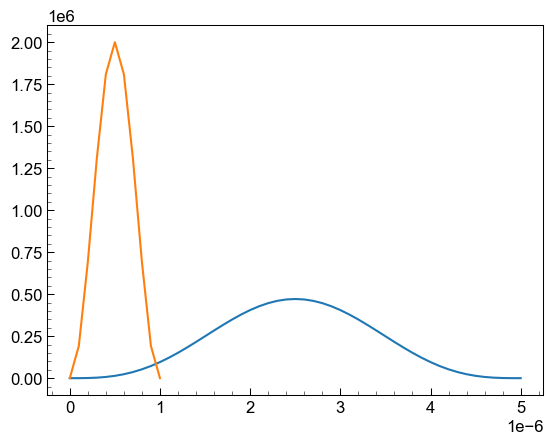

In [8]:
plt.plot(tvec_STF_input, stf_kupper_input)
plt.plot(np.hstack([tvec_STF_new, tvec_STF_new[-1]+dt]), np.hstack([stf_cos_new, 0]))

In [9]:
#---reconvolve STF---#
tr_green_xy_reconv=tr_green_xy.copy()
N = tr_green_xy.stats.npts # number of points on the green's function data
FS0 = np.fft.rfft(stf_kupper_input, N) # FFT of pre-convolved STF
FS1 = np.fft.rfft(stf_cos_new, N) # FFT of new STF
tmp1 = FS1 * np.conjugate(FS0) # dot product
tmp2 = np.maximum(np.abs(FS0)**2, (k_waterlevel_green*np.abs(FS0).max())**2)
FX0 = np.fft.rfft(tr_green_xy.copy().taper(0.05).data, N)
FX1= (tmp1/tmp2)*FX0
tr_green_xy_reconv.data = np.fft.irfft(FX1, N).real
#--------------------------#

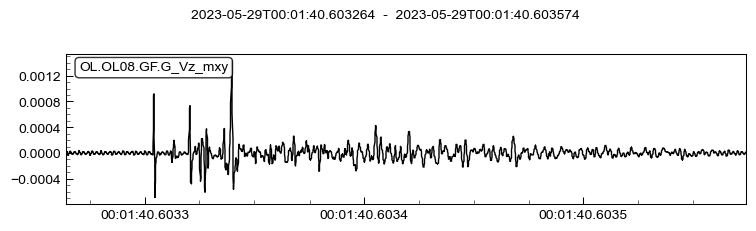

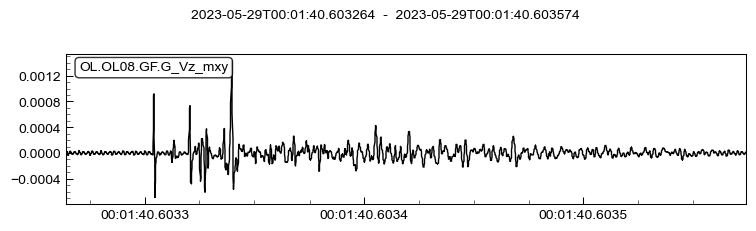

In [10]:
tr_green_xy_reconv.plot()

In [11]:
tr_green_xy_reconv_disp=tr_green_xy_reconv.copy()
tr_green_xy_reconv_disp.integrate(method='cumtrapz')

OL.OL08.GF.G_Vz_mxy | 2023-05-29T00:01:40.60326400Z - 2023-05-29T00:01:40.60357400Z | 10000000.0 Hz, 3101 samples

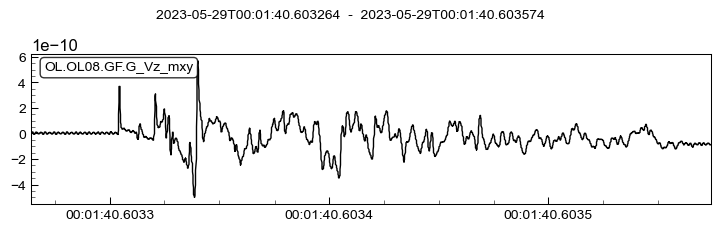

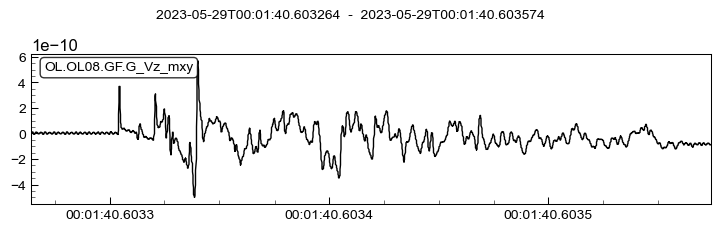

In [12]:
tr_green_xy_reconv_disp.plot()

# Apply band-pass filter
We apply the band-pass filter used for the evaluation of the pulse width measurement.

In [13]:
# Parameters for filtering
# We use the same filter as the previously analyzed gouge events
freqmin = 0.1e6 #0.06e6 # apply highpass
freqmax = 1.0e6 # 1e6 # prefilter is applied when removing the instrumental response. pre_filt = (1e4, 2e4, 1e6, 2e6).

butterworth_order = 3

In [14]:
b, a = signal.butter(butterworth_order, (freqmin, freqmax), 'bandpass', fs=tr_green_xy_reconv.stats.sampling_rate, output='ba')

tr_green_xy_reconv_filtered = tr_green_xy_reconv.copy().taper(0.05)
tr_green_xy_reconv_filtered.data = signal.filtfilt(b, a, tr_green_xy_reconv_filtered.data, method='gust') # using two-way filter Gustafsson’s method

# compute displacement
tr_green_xy_reconv_filtered_disp = tr_green_xy_reconv_filtered.copy()
tr_green_xy_reconv_filtered_disp.integrate(method='cumtrapz')

OL.OL08.GF.G_Vz_mxy | 2023-05-29T00:01:40.60326400Z - 2023-05-29T00:01:40.60357400Z | 10000000.0 Hz, 3101 samples

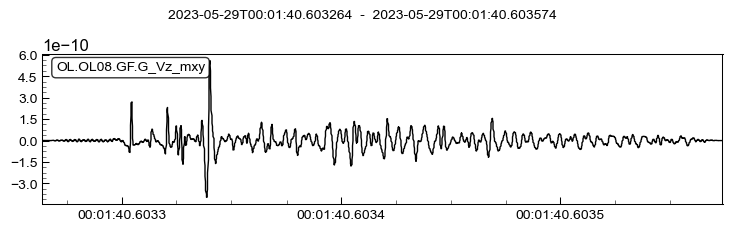

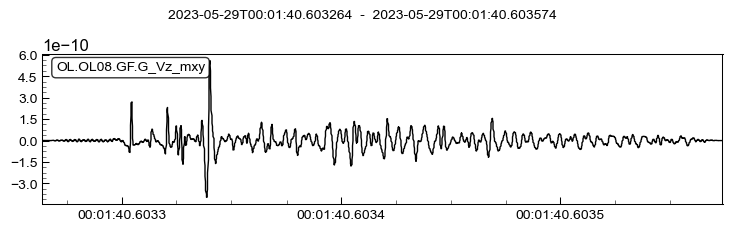

In [15]:
tr_green_xy_reconv_filtered_disp.plot()

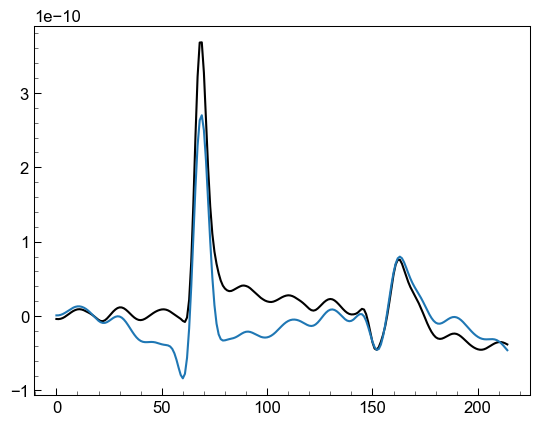

In [16]:
plt.plot(tr_green_xy_reconv_disp.data[335:550], "k")
plt.plot(tr_green_xy_reconv_filtered_disp.data[335:550])

## Summary plot

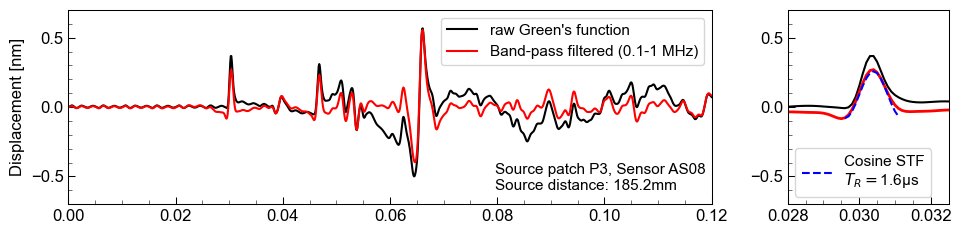

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# parameters
vp = 6200.0  # P-wave velocity [m/s]
dist = tr_obs.stats.dist  # distance between AE source and sensor [m]

# compute P-wave arrival time (sec → ms)
t_arrival = dist / vp  # [s]
t_arrival_ms = t_arrival * 1e3

# time vector in ms
pretrigger = tr_obs.stats.pretrigger

tvec_ms = (tr_green_xy_reconv_disp.times()-pretrigger*1e-3) * 1e3


# prepare figure
fig, axs = plt.subplots(1, 2, figsize=(10, 2.5),
                        gridspec_kw={'width_ratios': [4, 1]})

# ------------- LEFT COLUMN: full waveform (raw & filtered) -------------
xlimit=[0, 0.12]

ax = axs[0]
ax.plot(tvec_ms, tr_green_xy_reconv_disp.data*1e9, "k", label="raw Green's function")
ax.plot(tvec_ms, tr_green_xy_reconv_filtered_disp.data*1e9, "r", label="Band-pass filtered (0.1-1 MHz)")
ax.set_ylabel("Displacement [nm]")
ax.set_xlim(xlimit)
ax.set_ylim([-0.7, 0.7])
ax.legend(loc=1, fontsize=11)

text=f"Source patch {gougepatch_id}, Sensor AS{stationid:02d}\nSource distance: {dist:.1f}mm"
ax.text(0.0795, -0.6, text, fontsize=11)

# plot zoom
zoomwin_pre = 0.002
zoomwin_len = 0.003

# xlimit_zoom = [t_arrival-zoomwin_pre, t_arrival+zoomwin_len]
xlimit_zoom = [0.028, 0.0325] # manually set

# layout
ax = axs[1]
ax.plot(tvec_ms, tr_green_xy_reconv_disp.data*1e9, "k", label=None)
ax.plot(tvec_ms, tr_green_xy_reconv_filtered_disp.data*1e9, "r", label=None, lw=2)
# ax.set_ylabel("Displacement [nm]")
ax.set_ylim([-0.7, 0.7])
ax.set_xlim(xlimit_zoom)

# Fitting synthetic cosine STF 
TR_fit = 1.6e-6 # fitting STF source duration, which corresponds to the minimum resolution for the band-pass filter
tvec_STF = np.arange(np.ceil(TR_fit/dt)) * dt # time vector of new STF
M0_fit = 2.7e-7 # fit to the STF amplitude, as not converted to moment rate. Here is not the actual moment.
STF_fit = stf_cosine(tvec_STF, TR_fit, M0_fit)

STF_fit_tshift = 0.0296
STF_fit_yshift = -0.08

ax.plot(tvec_STF*1e3 + STF_fit_tshift, STF_fit+STF_fit_yshift, "b--", label=f"Cosine STF\n$T_R=${TR_fit*1e6:.1f}μs")
ax.legend(loc=0, fontsize=11)

fig.tight_layout()

plt.savefig(figdir+f"/revision_bandpass_resolution_eventID{event_id}.png", format="png", dpi=300, bbox_inches='tight')


# Apply attenuation factor

We apply the median attenuation model to the Green’s function.

Theory:

$$ y(\omega) = s(\omega)\, G(\omega;\mathbf{x})\, B(\omega),$$

where

$$ B(\omega) = \exp\left(-\frac{\omega t}{2\, Q(\omega)}\right).$$

We convolve $B(\omega)$ with the Green’s function to mimic the path effect.

Here, we conduct the analysis to show the bias introduced by the water level during the deconvolution of the attenuation factor.

To demonstrate this, we plot the waveforms as

$$ y(t)= \text{IFFT}\left[\frac{G * B^{\text{original}}}{B^{\text{w.\,waterlevel}}}\right]. $$

The P-wave displacement pulse after deconvolution indicates the minimum resolvable pulse width caused by the limitation associated with the attenuation correction using the water level.

## Read the attenuation model

In [18]:
# read Q model
df_Qinv_quantile = pd.read_csv("../../../../Calibration/Attenuation/data/df_Qinv_quantile.csv", index_col=0)
df_Qinv_quantile.head()

,freq,Qinv_25,Qinv_50,Qinv_75
0,0.039062,0.013403,0.036839,0.048583
1,0.078125,0.009528,0.018667,0.036067
2,0.117188,0.007164,0.016207,0.023822
3,0.156250,0.004907,0.010891,0.017656
4,0.195312,0.004253,0.008820,0.014757


In [19]:
def get_Qinv(freq, fq, Qinv):
    # interpolate the Q from the Qinv data
    cs = CubicSpline(fq, Qinv)
    
    Qinv_interp = np.zeros(len(freq))
    for i, ff in enumerate(freq):
        if ff<fq[0]:
            Qinv_interp[i] = Qinv[0] # extrapolate the minimum frequency Qinv
        elif ff>fq[-1]:
            Qinv_interp[i] = Qinv[-1] # extrapolate the maximum frequency Qinv
        else:
            Qinv_interp[i] = cs(ff)  
                
    return Qinv_interp

In [20]:
# parameters of deconvolution
Ndata_FFT = tr_green_xy_reconv.stats.npts
# NFFT = 2**(Ndata-1).bit_length()
NFFT = Ndata_FFT # same length of the data for the sake of simplicity
print(Ndata_FFT, NFFT)

3101 3101


Text(0, 0.5, 'Attenuation, $Q^{-1}$')

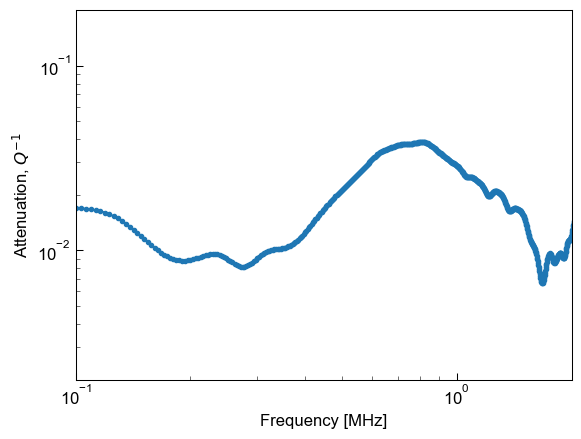

In [21]:
# test reading the Qinv
F_freq = np.fft.rfftfreq(NFFT, d=dt)

Qinv_50 = get_Qinv(F_freq, df_Qinv_quantile.freq.values*1e6, df_Qinv_quantile[f"Qinv_50"].values).astype(complex)
plt.loglog(F_freq/1e6, Qinv_50.real, ".-")
    
plt.xlim([0.1, 2])
plt.ylim([0.002, 0.2])
plt.xlabel("Frequency [MHz]")
plt.ylabel("Attenuation, $Q^{-1}$")


## Compute $B(\omega)$

In [22]:
print(f"source distance: {tr_obs.stats.dist:.3f} mm")

source distance: 185.159 mm


In [23]:
dist_gouge = tr_obs.stats.dist *1e-3 # gouge event distance
vp = 6200
tt = dist_gouge/vp

print(f"travel time: {tt*1e6:.2f} μs")

Bf = np.exp(-np.pi * F_freq * tt * Qinv_50)


travel time: 29.86 μs


## Compute $B(\omega)$ with waterlevel

In [24]:
k_waterlevel = 0.3 # same value used in the main analysis

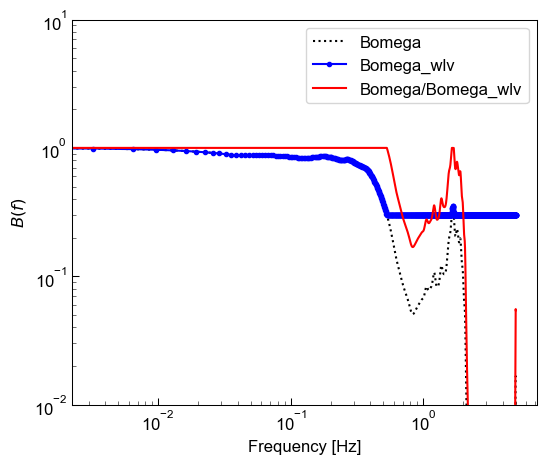

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(6., 5))
     
# debug plot Bomega with waterlevel
Bf_wlv = np.maximum(np.abs(Bf), (k_waterlevel*np.abs(Bf).max()))
ax.loglog(F_freq/1e6, Bf.real, ":", c="k", label="Bomega")
ax.loglog(F_freq/1e6, Bf_wlv.real, ".-", c="b", label="Bomega_wlv")
ax.loglog(F_freq/1e6, Bf.real/Bf_wlv.real, "-", c="r", label="Bomega/Bomega_wlv")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("$B(f)$")

# ax.set_xlim([0.06,1.])
# ax.set_xlim([1e-3 ,1.])
ax.set_ylim([1e-2, 1e1])
ax.legend()

## Apply attenuation factor for each AE sensor

1. Read and synthesize the Green's function for the four AE sensors.
2. Compute $B(\omega)$
3. Compute waveforms
4. Store in the stream

In [26]:
st_attenuation_G = Stream()
st_attenuation_GB = Stream()
st_attenuation_GB_deconwlv = Stream()

stationid_list = [23, 7, 8, 22]
for stationid in stationid_list:
    
    # 1. read and synthesize the Green's function
    tr_obs = st_event.select(station=f'OL{stationid:02d}', location='stage1')[0].filter("highpass", freq=6e4)
    tr_green_xy = st_event.select(station=f'OL{stationid:02d}', location='GF', channel='G_Vz_mxy')[0]
    
    #---reconvolve STF---#
    tr_green_xy_reconv=tr_green_xy.copy()
    N = tr_green_xy.stats.npts # number of points on the green's function data
    FS0 = np.fft.rfft(stf_kupper_input, N) # FFT of pre-convolved STF # STF is common for all the sensors
    FS1 = np.fft.rfft(stf_cos_new, N) # FFT of new STF
    tmp1 = FS1 * np.conjugate(FS0) # dot product
    tmp2 = np.maximum(np.abs(FS0)**2, (k_waterlevel_green*np.abs(FS0).max())**2)
    FX0 = np.fft.rfft(tr_green_xy.copy().taper(0.05).data, N)
    FX1= (tmp1/tmp2)*FX0
    tr_green_xy_reconv.data = np.fft.irfft(FX1, N).real
    #--------------------------#
    
    # 2. Compute B(omega)
    dist_gouge = tr_obs.stats.dist *1e-3 # gouge event distance; this varies with the sensors
    tt = dist_gouge/vp
    tr_green_xy_reconv.stats.dist = dist_gouge
    tr_green_xy_reconv.stats.tp = tt
    
    print(f"travel time: {tt*1e6:.2f} μs")
    
    Bf_sensor = np.exp(-np.pi * F_freq * tt * Qinv_50)
    Bf_sensor_wlv = np.maximum(np.abs(Bf_sensor), (k_waterlevel*np.abs(Bf_sensor).max()))
    
    # # debug plot Bomega with waterlevel
    # plt.loglog(F_freq/1e6, Bf_sensor.real, ":", c="k", label="Bomega")
    # plt.loglog(F_freq/1e6, Bf_sensor_wlv.real, ".-", c="b", label="Bomega_wlv")
    # plt.loglog(F_freq/1e6, Bf_sensor.real/Bf_sensor_wlv.real, "-", c="r", label="Bomega/Bomega_wlv")
    # plt.ylim([1e-2, 1e1])
    # plt.legend()
    
    # 3. Apply the attenuation factor to the Green's function
    tr_green_xy_reconv_B = tr_green_xy_reconv.copy()
    tr_green_xy_reconv_B_decon_Bwlv = tr_green_xy_reconv.copy()
    
    FX0 = np.fft.rfft(tr_green_xy_reconv.data)
    tr_green_xy_reconv_B.data = np.fft.irfft(FX0 * Bf_sensor, N).real
    tr_green_xy_reconv_B_decon_Bwlv.data = np.fft.irfft(FX0 * Bf_sensor/Bf_sensor_wlv, N).real
    
    # 4. Store to the stream
    st_attenuation_G.append(tr_green_xy_reconv)
    st_attenuation_GB.append(tr_green_xy_reconv_B)
    st_attenuation_GB_deconwlv.append(tr_green_xy_reconv_B_decon_Bwlv)

travel time: 15.81 μs
travel time: 19.11 μs
travel time: 29.86 μs
travel time: 36.73 μs


In [27]:
st_attenuation_G

4 Trace(s) in Stream:
OL.OL23.GF.G_Vz_mxy | 2023-05-29T00:01:40.60326400Z - 2023-05-29T00:01:40.60357400Z | 10000000.0 Hz, 3101 samples
OL.OL07.GF.G_Vz_mxy | 2023-05-29T00:01:40.60326400Z - 2023-05-29T00:01:40.60357400Z | 10000000.0 Hz, 3101 samples
OL.OL08.GF.G_Vz_mxy | 2023-05-29T00:01:40.60326400Z - 2023-05-29T00:01:40.60357400Z | 10000000.0 Hz, 3101 samples
OL.OL22.GF.G_Vz_mxy | 2023-05-29T00:01:40.60326400Z - 2023-05-29T00:01:40.60357400Z | 10000000.0 Hz, 3101 samples

# Plot the traces

In [28]:
tt

3.6728137720502975e-05

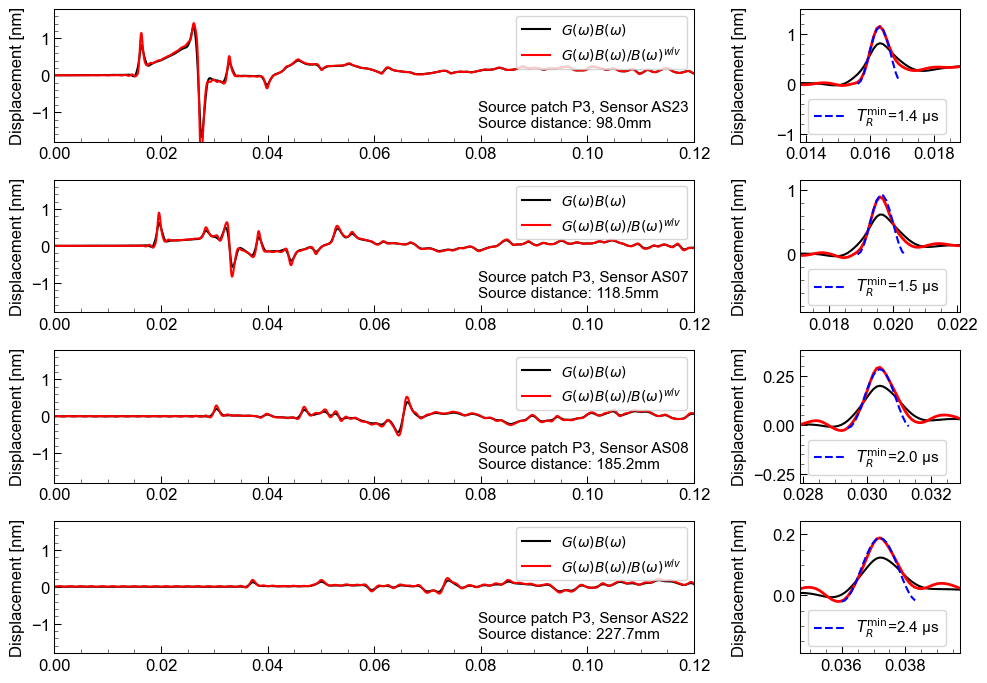

In [29]:
# prepare figure
fig, axs = plt.subplots(4, 2, figsize=(10, 7),
                        gridspec_kw={'width_ratios': [4, 1]})

# ------------- LEFT COLUMN: full waveform (raw & filtered) -------------
xlimit=[0, 0.12]
ylimit = [-1.8, 1.8]

plot_polarity = [-1, -1, 1, 1] # depending on the side of sensor installation

for i, stationid in enumerate(stationid_list):

    polarity = plot_polarity[i]
    
    tr_green_xy_reconv = st_attenuation_G.select(station=f"OL{stationid:02d}")[0].copy()
    tr_green_xy_reconv_B = st_attenuation_GB.select(station=f"OL{stationid:02d}")[0].copy()
    tr_green_xy_reconv_B_decon_wlv = st_attenuation_GB_deconwlv.select(station=f"OL{stationid:02d}")[0].copy()

    # integrate to compute the displacement
    tr_green_xy_reconv_B.integrate(method='cumtrapz')
    tr_green_xy_reconv_B_decon_wlv.integrate(method='cumtrapz')
    
    dist = tr_green_xy_reconv.stats.dist * 1e3
    t_arrival_ms = tr_green_xy_reconv.stats.tp * 1e3
    tvec_ms = (tr_green_xy_reconv.times()-pretrigger*1e-3) * 1e3

    ax = axs[i, 0]
    ax.plot(tvec_ms, polarity*tr_green_xy_reconv_B.data*1e9, "k", label="$G(ω)B(ω)$")
    ax.plot(tvec_ms, polarity*tr_green_xy_reconv_B_decon_wlv.data*1e9, "r", label="$G(ω)B(ω)/B(ω)^{wlv}$")
    ax.set_ylabel("Displacement [nm]")
    ax.set_xlim(xlimit)
    ax.set_ylim(ylimit)
    ax.legend(loc=1, fontsize=10)

    text=f"Source patch {gougepatch_id}, Sensor AS{stationid:02d}\nSource distance: {dist:.1f}mm"
    ax.text(0.0795, -1.4, text, fontsize=11)
    
    # plot zoom
    zoomwin_pre = 0.002        
    zoomwin_len = 0.005
    xlim_zoom_st = np.round(t_arrival_ms-zoomwin_pre, 4)
    xlimit_zoom = [xlim_zoom_st, xlim_zoom_st+zoomwin_len]
    # xlimit_zoom = [0.028, 0.0325] # manually set
    
    # # layout
    ax = axs[i, 1]
    ax.plot(tvec_ms, polarity*tr_green_xy_reconv_B.data*1e9, "k", label=None)
    ax.plot(tvec_ms, polarity*tr_green_xy_reconv_B_decon_wlv.data*1e9, "r", label=None, lw=2)
    ax.set_ylabel("Displacement [nm]")
    ax.set_xlim(xlimit_zoom)

    P_window = np.where((tvec_ms >= t_arrival_ms-zoomwin_pre) & (tvec_ms <= t_arrival_ms+zoomwin_len))
    ylim_val = np.max(polarity*tr_green_xy_reconv_B_decon_wlv.data[P_window]*1e9)
    ax.set_ylim([-1.0*ylim_val, 1.3*ylim_val])
    # ax.legend(loc=1, fontsize=10)


# Fitting synthetic cosine STF 
TR_fit_list = [1.4, 1.5, 2.0, 2.4] # μs
M0_fit_list = [0.8e-6, 0.7e-6, 3.0e-7, 2.5e-7] # fit to the STF amplitude, as not converted to moment rate. Here is not the actual moment.
STF_fit_tshift_list = [0.0156, 0.0189, 0.0294, 0.036]
STF_fit_yshift_list = [0, 0, -0.015, -0.02]

for i, stationid in enumerate(stationid_list):

    tvec_STF = np.arange(np.ceil(TR_fit_list[i]*1e-6/dt)) * dt # time vector of new STF
    STF_fit = stf_cosine(tvec_STF, TR_fit_list[i]*1e-6, M0_fit_list[i])

    label = r"$T_R^{\mathrm{min}}$" + f"={TR_fit_list[i]:.1f} μs"

    axs[i, 1].plot(tvec_STF*1e3 + STF_fit_tshift_list[i], STF_fit+STF_fit_yshift_list[i], "b--", label=label)
    axs[i, 1].legend(loc=0, fontsize=11)

fig.align_ylabels()

fig.tight_layout()

plt.savefig(figdir+f"/revision_attenuation_resolution_eventID{event_id}.png", format="png", dpi=300, bbox_inches='tight')


In [30]:
print(f"average minimum TR = {np.mean(TR_fit_list):.3f} μs")

average minimum TR = 1.825 μs
